<a href="https://colab.research.google.com/github/mf1060/ml-2026/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Michael Furey

Dr. Forouraghi

Machine Learning

September 14, 2026

The following notebook describes the analysis and findings for Assignment 2. The purpose of this assignment is to analyze a dataset on cybersecurity intrusions which is open-sourced on [Kaggle](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset). Our goals are to identify which variables have a measured effect on whether an attack was detected. This involves importing Python libraries to clean and standardize this data. Then, we will take steps to observe which variables run with the target variable, `attack_detected` using a Person correlation. This notebook uses code and methods from the class [End-to-End Machine Learning Project](https://github.com/bforoura/ML26/blob/main/Module2_ML_Projects/02_end_to_end_machine_learning_project.ipynb), the Module 2 Overview for this class, the Module 2 videos, and Chapter 2 of our textbook (Aurélien Géron, Hands-On Machine Learning with SciKit-Learn and PyTorch (2025)).

The following block imports necessary libraries for this project.

In [1]:
import pandas as pd

from packaging.version import Version
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

assert Version(sklearn.__version__) >= Version("1.6.1")

# Loading dataset



This notebook uses a dataset of real world cybersecurity intrusion detection from [Kaggle](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset).


In [2]:
cyber_full = pd.read_csv('https://raw.githubusercontent.com/mf1060/ml-2026/refs/heads/main/HW2/data/cybersecurity_intrusion_data.csv')

# Inspection Methods

We will first use some inspection methods to get a sense of what this data looks like.

We first use `.head()` to view the first 5 rows of this dataframe. We can see how each column stores values.

In [3]:
cyber_full.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


The Pandas `.info()` method describes what values are missing. We observe that taking a summary of the values in the data there are 9537 entries in total. We can see that the field, `enryption_used` has 1,966 null fields which will require imputation.

In [4]:
cyber_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


As Module 2, part 3 video discusses, the Pandas `.describe()` method takes summary statistics of numeric values. This method can be used to look at mean, standard deviation, and interquartile ranges. We can see that `login_attempts` range from 1-3, `failed_logins` range from 0-5 and that `ip_reputation_score` ranges from 0-1.

In [5]:
cyber_full.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


# Creating a Test Set

As our class discussion and textbook It is generally a good idea to create a test and training set. We can use the following method to do so which sets aside about 20% of the data for testing. We use a `random_state` of 42 so that we randomize the data to the same value each time we run the notebook.

In [6]:
from sklearn.model_selection import train_test_split

cyber_train_set, cyber_test_set = train_test_split(cyber_full, test_size=0.2,
                                       random_state=42)

# Dropping Non-Informative Identifiers

The Module 2, Part 3 video discusses some fields that may not be useful to our analysis. For instance, we may want to drop `session_id` because we would not need to summarize or analyze these values.

In [7]:
# Dropping session id
cyber_train_set.drop("session_id", axis=1, inplace=True)

# Imputation
We learned that `encryption_type` had null values. We can use `.value_counts()` on that column to determine the right [strategy](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) we should use for imputing categorical variables. For instance, we can replace values with the most frequently used value or a constant value like: "unknown."



In [8]:
cyber_train_set['encryption_used'].value_counts()

,count
encryption_used,
AES,3716
DES,2317


Because one encryption method has not been used more than others, we may want to impute the missing values with a contstant value such as "unknown." This way, we do not bias the dataset by filling in one encryption method over any other.

# Isolating Numerical and Categorical Features

The following takes steps to analyze numeric values and categorical values.







# Isolating Numeric Features

We can isolate numeric features by using the method `.select_dtypes("number")`.

In [9]:
# Getting the numeric subset (only the ones that may need to be standardized)
cyber_num = cyber_train_set.select_dtypes("number")
cyber_num

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
1323,597,2,399.443662,0.108287,3,0,1
2742,508,6,18.228910,0.062956,1,0,1
3582,884,3,1461.455154,0.178484,1,0,0
5688,246,5,620.786731,0.437060,2,1,0
1614,463,4,432.403972,0.308825,1,0,0
...,...,...,...,...,...,...,...
5734,385,8,1291.182244,0.326769,2,0,1
5191,491,4,917.566085,0.465352,2,0,0
5390,360,2,179.322789,0.177113,0,0,0
860,540,3,85.078400,0.456961,2,0,0


We can see how to apply some scaling to numeric features by taking a histogram of each value. We would like to see values normally distributed in order to apply machine learning methods of analysis.

array([[<Axes: title={'center': 'network_packet_size'}>,
        <Axes: title={'center': 'login_attempts'}>,
        <Axes: title={'center': 'session_duration'}>],
       [<Axes: title={'center': 'ip_reputation_score'}>,
        <Axes: title={'center': 'failed_logins'}>,
        <Axes: title={'center': 'unusual_time_access'}>],
       [<Axes: title={'center': 'attack_detected'}>, <Axes: >, <Axes: >]],
      dtype=object)

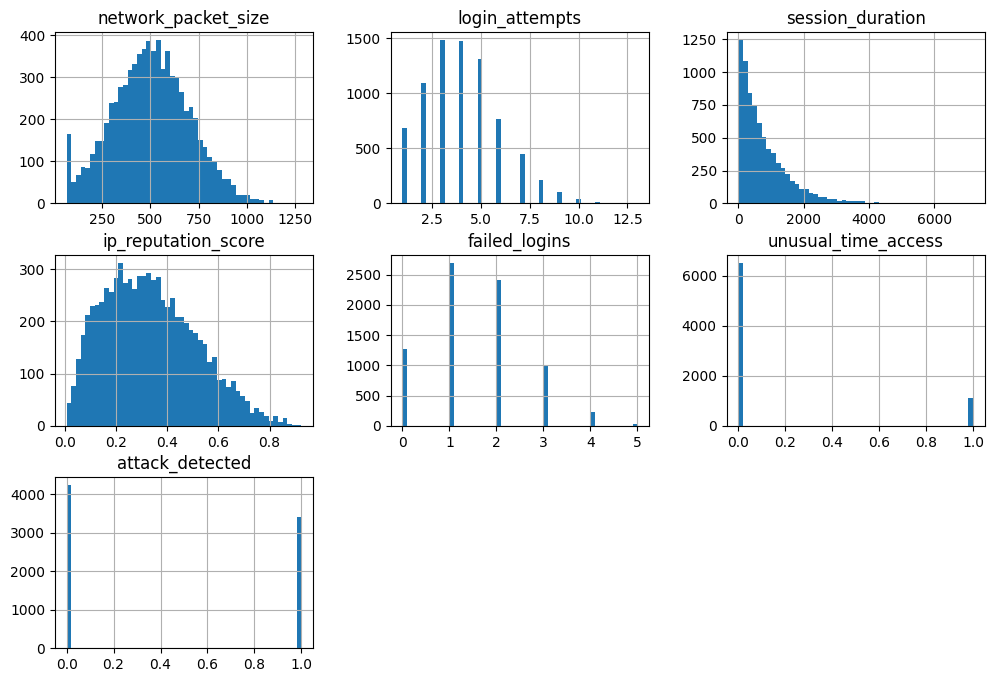

In [10]:
cyber_num.hist(bins=50, figsize=(12, 8))

When taking a histogram, we can see a number of these values are binary or have discrete values such as login attempts and failed logins. Values such as network packet size and ip reputation score appear normally distributed with a characteristic bell curve. We can still apply a standardization method to them.

`session_duration` has a particularly long tail to the right while most of its density is at lower values. While we we can standardize these values, we should also use a log scaler to create a bell curve.

# Isolating Categoric Features

The following are categorical features: `protocol type`, `encryption_used`, and `browser_type`. For these values, we we would want to (1) impute a constant for missing values and (2) create a one-hot encoding which would create dummy variables for each category.  

In [11]:
cyber_cat = cyber_train_set.select_dtypes("object")
cyber_cat

,protocol_type,encryption_used,browser_type
1323,UDP,NaN,Chrome
2742,UDP,AES,Edge
3582,TCP,AES,Chrome
5688,TCP,AES,Chrome
1614,TCP,NaN,Chrome
...,...,...,...
5734,ICMP,NaN,Chrome
5191,UDP,DES,Edge
5390,TCP,NaN,Firefox
860,TCP,AES,Chrome


# Preparing the Pipeline

The following discusses how to create a pipeline with a ColumnTransformer so that numeric and categorical columns can be adjusted together. In order to create a log transformer, we would create one using Chapter 2 of our textbook (pg. 160 of the full book linked to our class and pg. 15 of the Module 2 overview).

In [12]:
#Importing the method for a pipeline
from sklearn.pipeline import Pipeline
#Importing a simple imputer for filling empty values
from sklearn.impute import SimpleImputer
#Importing a one hot encoder for creating dummy variables for categorical data
from sklearn.preprocessing import OneHotEncoder
#Importing libraries for creating pipelines and a transformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
#Importing a Standard Scaler to standardize values.
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_selector, make_column_transformer


# Using methods from "end-to-end machine learning project"
# Using log scaling methods from pg. 160 of the full textbook linked to our class.
# Also Referencing a logtransformer method from: https://docs.kanaries.net/topics/Scikit-Learn/sklearn-pipeline
from sklearn.preprocessing import FunctionTransformer

# The following defines a pipeline for log-scaling values. We first impute the
#median for missing values, we apply a log function to each value, and then a
#standard scaler.
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

#The following defines the pipeline for all other numeric values. We first
#impute the median and then apply a standard scaler.
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

#The following defines the pipeline for categorical values. We first impute the
#missing values with a constant, "Unknown", then we apply a one-hot encoder to
#all categorical values.
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="Unknown"),
    OneHotEncoder(handle_unknown="ignore")
)

#The following defines a preprocessor pipeline that combines the others.
#First, session_duration is log-scaled using the log_pipeline
#Then, any categorical variables are processed with the cat_pipeline
#Finally, all other numeric variables are transformed using the default numeric
#pipeline.
preprocessing = ColumnTransformer([
        ("log", log_pipeline, ["session_duration"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline
)

Now, we apply the preprocessing pipeline to our training set.

In [13]:
cyber_prepared = preprocessing.fit_transform(cyber_train_set)

cyber_columns = preprocessing.get_feature_names_out()

new_df = pd.DataFrame(cyber_prepared, columns=cyber_columns, index=cyber_train_set.index)

When running the a histogram on the numeric values, we can see that they are standardized, inclusing session-duration which is log-scaled to have a normal distribution.

array([[<Axes: title={'center': 'log__session_duration'}>,
        <Axes: title={'center': 'remainder__network_packet_size'}>],
       [<Axes: title={'center': 'remainder__ip_reputation_score'}>,
        <Axes: >]], dtype=object)

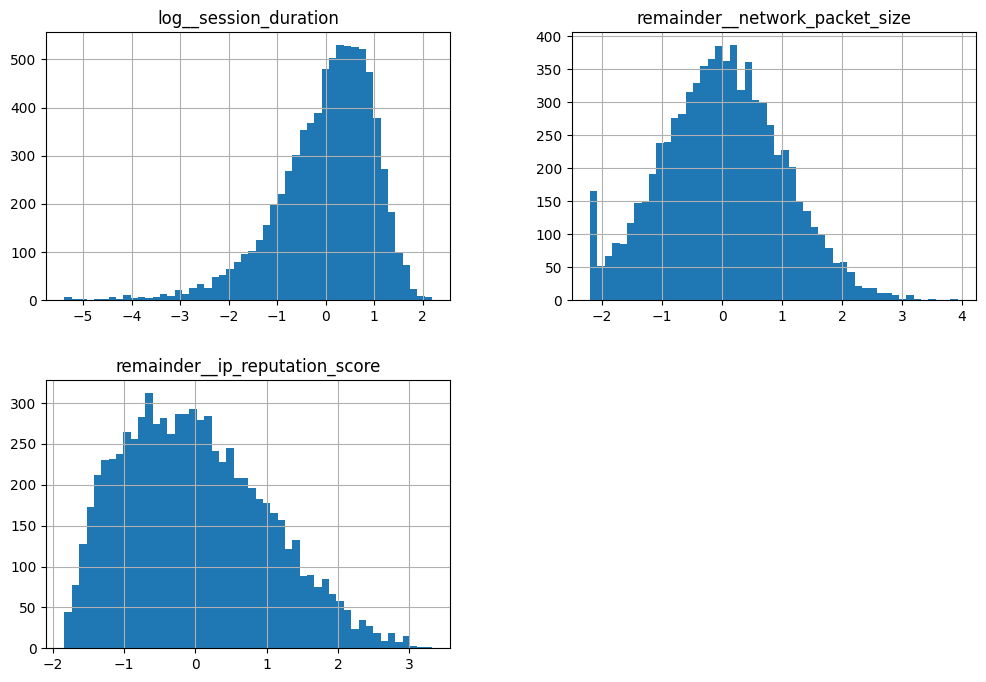

In [14]:
num_columns = ['log__session_duration', 'remainder__network_packet_size', 'remainder__ip_reputation_score']
new_df[num_columns].hist(bins=50, figsize=(12, 8))

# Computing Pearson Correlation

The Module 2, part 3 video describes how one can create a heatmap to examine the relationship between all of the features of the dataset and the variable of interest, in this case `attack_detected`.

The following uses code described in the Module 2, Part 3 video. Below, we see higher correlations between attacks detected and `login_attempts`, `ip_reputation_score`, and `failed_logins`.

<Axes: >

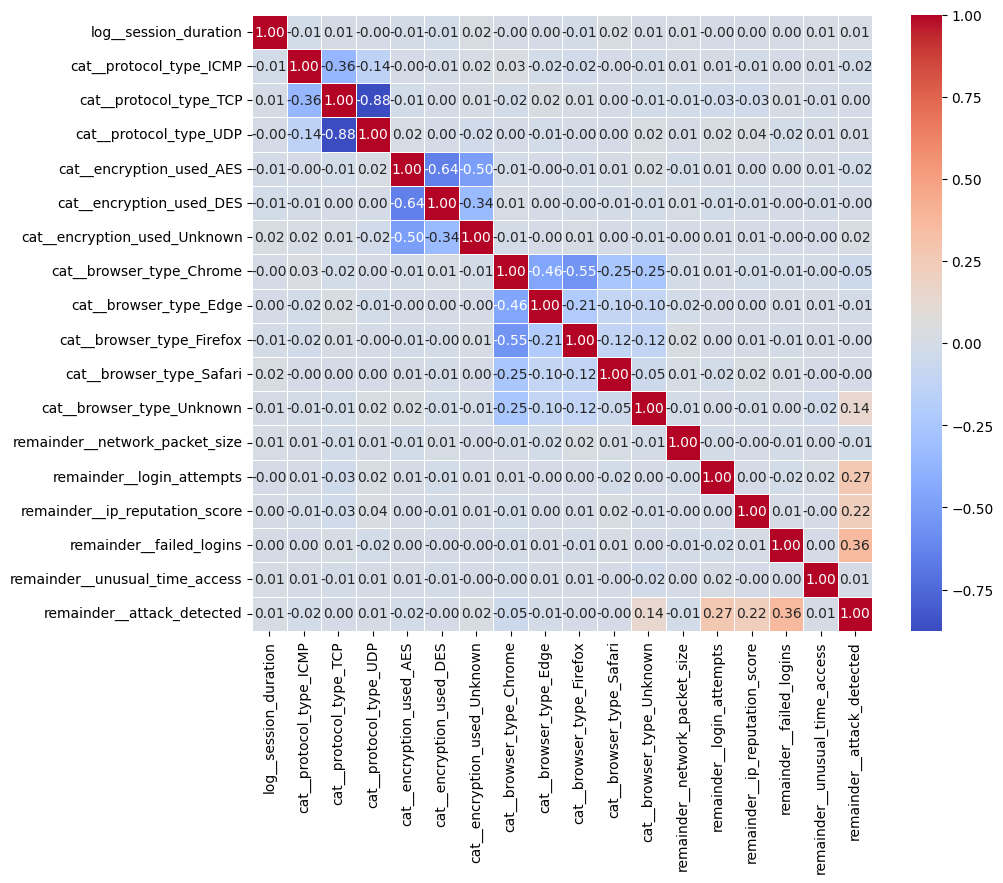

In [15]:
#Creating a correlation matrix between all numeric values described in .info()
corr_matrix = new_df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)



We can run a scatter matrix in order to visualize some of these correlations. While we do not see a typical linear correlation, we can see (in the bottom row) that higher values of `ip_reputation_score`, `failed_logins`, and `login_attempts` correspond more to a value of 1 for when an attack is detected.

array([[<Axes: xlabel='remainder__login_attempts', ylabel='remainder__login_attempts'>,
        <Axes: xlabel='remainder__ip_reputation_score', ylabel='remainder__login_attempts'>,
        <Axes: xlabel='remainder__failed_logins', ylabel='remainder__login_attempts'>,
        <Axes: xlabel='remainder__attack_detected', ylabel='remainder__login_attempts'>],
       [<Axes: xlabel='remainder__login_attempts', ylabel='remainder__ip_reputation_score'>,
        <Axes: xlabel='remainder__ip_reputation_score', ylabel='remainder__ip_reputation_score'>,
        <Axes: xlabel='remainder__failed_logins', ylabel='remainder__ip_reputation_score'>,
        <Axes: xlabel='remainder__attack_detected', ylabel='remainder__ip_reputation_score'>],
       [<Axes: xlabel='remainder__login_attempts', ylabel='remainder__failed_logins'>,
        <Axes: xlabel='remainder__ip_reputation_score', ylabel='remainder__failed_logins'>,
        <Axes: xlabel='remainder__failed_logins', ylabel='remainder__failed_logins'>,

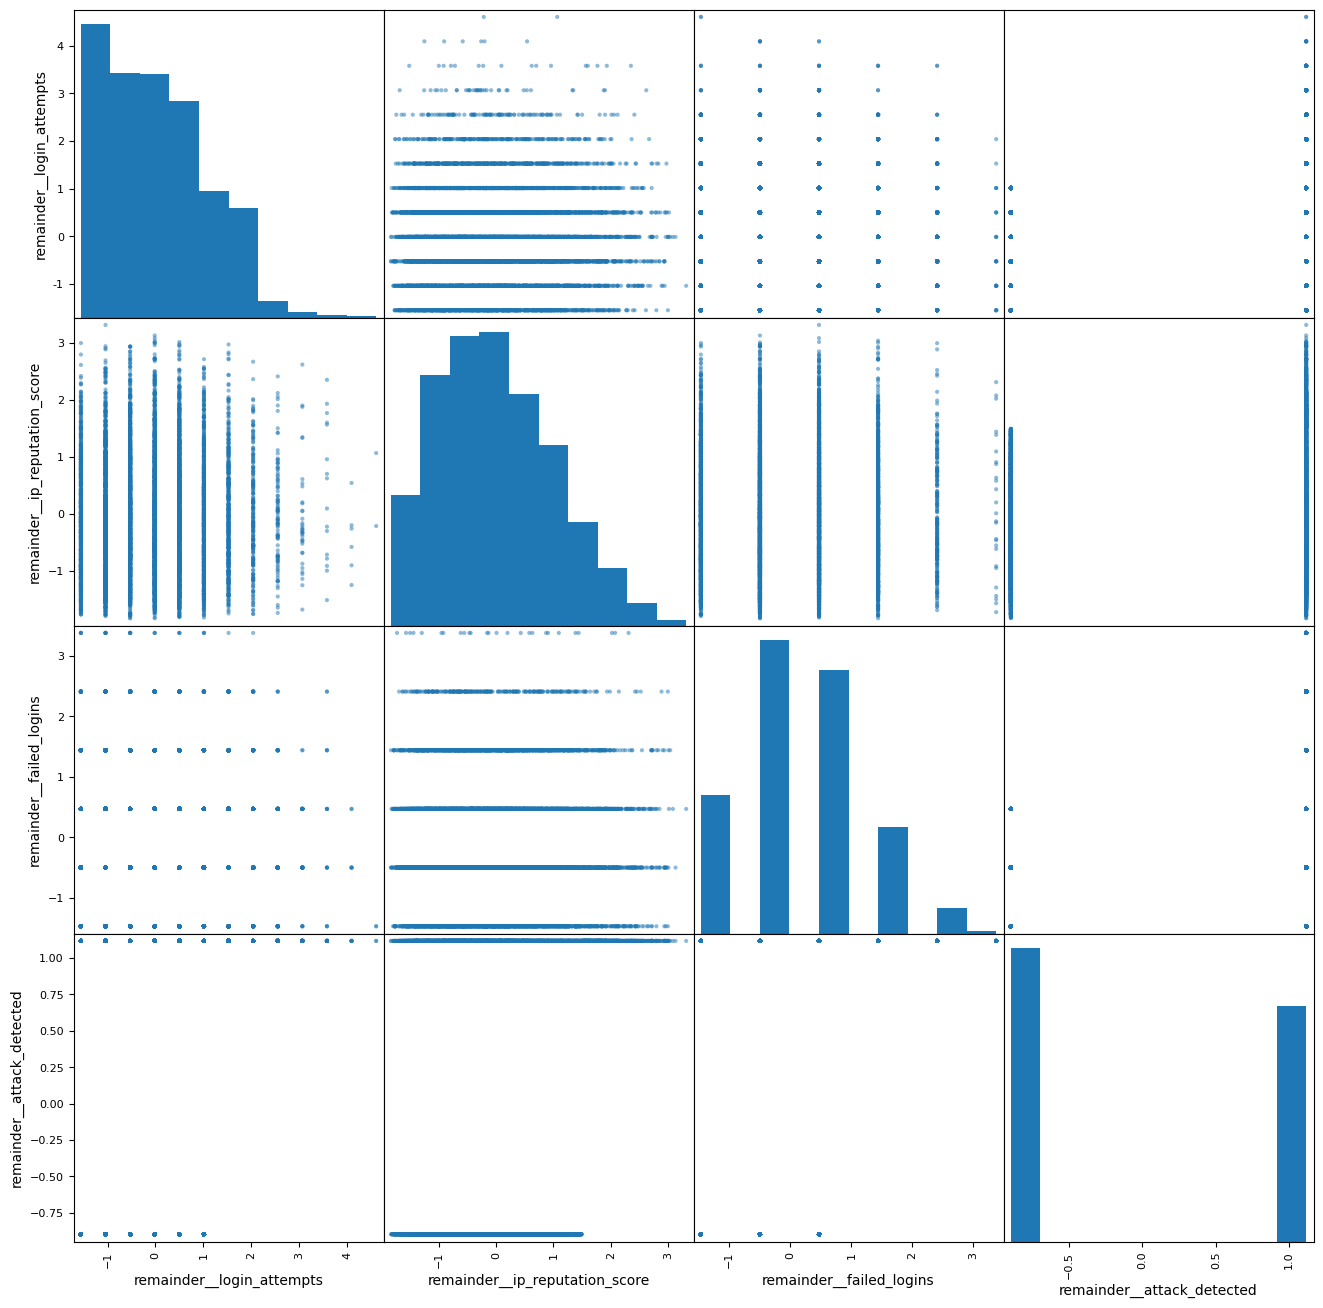

In [16]:
from pandas.plotting import scatter_matrix
columns = ["remainder__login_attempts", "remainder__ip_reputation_score", "remainder__failed_logins", "remainder__attack_detected"]
scatter_matrix(new_df[columns], figsize=(16, 16))